# SmartCare Hospital AI - Option C
## Explainable and Leakage-Aware Multiclass Disease-Risk Classification

**Target:** `disease_risk_level` (Low, Medium, High)  
**Prediction point:** Initial patient assessment, before admission, treatment, billing, or discharge.

## 1. Problem definition

SmartCare Hospital requires an interpretable machine-learning system that classifies patients into Low, Medium, and High disease-risk levels from structured information available during initial assessment. The system is intended as an educational decision-support prototype. It must not replace professional clinical judgement.

### Aim
Develop and evaluate a leakage-aware, explainable multiclass classification pipeline for the SmartCare dataset.

### Research questions
1. Which machine-learning algorithm achieves the strongest macro-F1 score?
2. Does diagnosis and hospital-history context improve a clinical-only model?
3. Which features influence Low, Medium, and High predictions?
4. Which class and class boundary cause the most errors?
5. How reliable are the predicted class probabilities?

### Research gap
The reviewed literature is dominated by disease-specific or population-specific studies, and several studies reuse the same small maternal-health dataset. Within that literature, limited work jointly examines a general-hospital three-level risk label with an explicit prediction-time feature audit, class-specific and ordinal error analysis, calibrated uncertainty, and both global and patient-level explanations. This project addresses that methodological gap on the supplied synthetic SmartCare dataset.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Display and plot settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

# Set file paths and check they exist
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "smartcare_ai_dataset_1000.csv"
DICTIONARY_PATH = PROJECT_DIR / "smartcare_ai_dataset_data_dictionary.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")
if not DICTIONARY_PATH.exists():
    raise FileNotFoundError(f"Data dictionary not found: {DICTIONARY_PATH}")

print(f"Project directory: {PROJECT_DIR}")

Project directory: c:\Users\Anjana\OneDrive\Desktop\smartcare-ai-risk-classification


## 2. Load the dataset and data dictionary

In [2]:
# Load dataset and data dictionary
df = pd.read_csv(DATA_PATH)
data_dictionary = pd.read_csv(DICTIONARY_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Data dictionary entries: {len(data_dictionary)}")
display(df.head())
display(data_dictionary)

Dataset shape: 1,000 rows x 33 columns
Data dictionary entries: 33


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


## 3. Dataset structure and attribute types

In [3]:
# Summary of each column type, missing values, unique values
structure = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values,
})
display(structure)

,column,dtype,non_null,missing,missing_pct,unique_values
0,record_id,int64,1000,0,0.0,1000
1,patient_id,object,1000,0,0.0,1000
2,age,int64,1000,0,0.0,88
3,gender,object,1000,0,0.0,2
4,blood_group,object,1000,0,0.0,8
5,department,object,1000,0,0.0,7
6,diagnosis,object,1000,0,0.0,10
7,appointment_date,object,1000,0,0.0,339
8,waiting_days,int64,1000,0,0.0,45
9,previous_appointments,int64,1000,0,0.0,10


In [4]:
# Split columns into numeric and categorical
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Categorical/date columns ({len(categorical_columns)}): {categorical_columns}")
display(df[numeric_columns].describe().T.round(2))

Numeric columns (22): ['record_id', 'age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'admitted', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'no_show', 'readmitted_30_days']
Categorical/date columns (11): ['patient_id', 'gender', 'blood_group', 'department', 'diagnosis', 'appointment_date', 'appointment_status', 'room_type', 'payment_status', 'payment_method', 'disease_risk_level']


,count,mean,std,min,25%,50%,75%,max
record_id,1000.0,500.50,288.82,1.0,250.75,500.5,750.25,1000.0
age,1000.0,44.74,17.85,1.0,33.00,44.0,57.00,90.0
waiting_days,1000.0,21.85,13.04,0.0,11.00,22.0,34.00,44.0
previous_appointments,1000.0,2.88,1.69,0.0,2.00,3.0,4.00,10.0
missed_previous_appointments,1000.0,0.55,0.74,0.0,0.00,0.0,1.00,4.0
admitted,1000.0,0.33,0.47,0.0,0.00,0.0,1.00,1.0
length_of_stay_days,1000.0,1.10,1.89,0.0,0.00,0.0,2.00,9.0
previous_admissions,1000.0,0.86,0.96,0.0,0.00,1.0,1.00,5.0
systolic_bp,1000.0,128.42,15.49,85.0,117.00,128.0,139.00,178.0
diastolic_bp,1000.0,78.83,10.04,50.0,72.00,79.0,86.00,111.0


## 4. Data-quality assessment

This section checks missing values, complete duplicates, duplicate identifiers, date validity, and logical consistency.

In [5]:
# Check for duplicates and missing values
quality_summary = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "complete_duplicate_rows": int(df.duplicated().sum()),
    "duplicate_record_ids": int(df["record_id"].duplicated().sum()),
    "duplicate_patient_ids": int(df["patient_id"].duplicated().sum()),
    "total_missing_cells": int(df.isna().sum().sum()),
})
display(quality_summary.to_frame("value"))

missing_table = structure.loc[structure["missing"] > 0,
                              ["column", "missing", "missing_pct"]]
display(missing_table if not missing_table.empty else pd.DataFrame({"result": ["No missing values"]}))

,value
rows,1000
columns,33
complete_duplicate_rows,0
duplicate_record_ids,0
duplicate_patient_ids,0
total_missing_cells,906


,column,missing,missing_pct
13,room_type,906,90.6


In [6]:
# Check for invalid appointment dates
appointment_dates = pd.to_datetime(df["appointment_date"], errors="coerce")
print(f"Invalid appointment dates: {appointment_dates.isna().sum()}")
print(f"Appointment date range: {appointment_dates.min().date()} to {appointment_dates.max().date()}")

Invalid appointment dates: 0
Appointment date range: 2025-01-01 to 2025-12-31


In [7]:
# Logical consistency checks
bill_components = (
    df["consultation_fee_lkr"]
    + df["room_charge_lkr"]
    + df["lab_charge_lkr"]
    + df["medicine_charge_lkr"]
)

logical_checks = pd.Series({
    "non_admitted_with_positive_stay": int(((df["admitted"] == 0) & (df["length_of_stay_days"] > 0)).sum()),
    "admitted_with_zero_stay": int(((df["admitted"] == 1) & (df["length_of_stay_days"] == 0)).sum()),
    "bill_total_mismatches": int((bill_components != df["total_bill_lkr"]).sum()),
    "missed_history_exceeds_previous_appointments": int((df["missed_previous_appointments"] > df["previous_appointments"]).sum()),
})
display(logical_checks.to_frame("count"))

# Check room_type missingness against admission status
display(pd.crosstab(df["admitted"], df["room_type"].fillna("Not recorded / not applicable")))

,count
non_admitted_with_positive_stay,0
admitted_with_zero_stay,0
bill_total_mismatches,0
missed_history_exceeds_previous_appointments,16


room_type,General Ward,ICU,Not recorded / not applicable,Private Room
admitted,,,,
0,0,0,670,0
1,52,9,236,33


### Missing-value interpretation

`room_type` is missing for many records. For non-admitted patients this is structurally not applicable, not an unknown clinical measurement. Because room assignment happens after the proposed prediction point, `room_type` will be excluded from the model rather than imputed.

## 5. Target-variable analysis

,count,percentage
disease_risk_level,,
Low,131,13.1
Medium,469,46.9
High,400,40.0


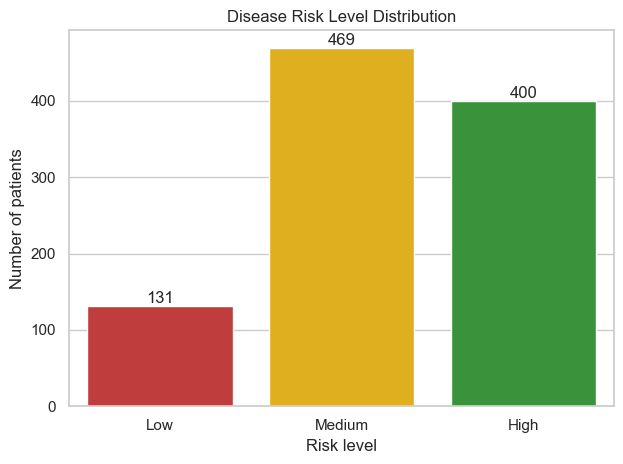

In [8]:
# Target variable distribution
TARGET = "disease_risk_level"
RISK_ORDER = ["Low", "Medium", "High"]

target_counts = df[TARGET].value_counts().reindex(RISK_ORDER)
target_percentages = (df[TARGET].value_counts(normalize=True).reindex(RISK_ORDER) * 100).round(1)
target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})
display(target_summary)

# Plot the class distribution
ax = sns.countplot(data=df, x=TARGET, order=RISK_ORDER, hue=TARGET,
                   palette=["#2ca02c", "#ffbf00", "#d62728"], legend=False)
ax.set_title("Disease Risk Level Distribution")
ax.set_xlabel("Risk level")
ax.set_ylabel("Number of patients")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

The Low class is the minority class. Later modelling should therefore use stratified splitting and report macro-F1 and per-class metrics in addition to accuracy. Class weighting should be tested before synthetic oversampling.

## 6. Feature-availability and leakage policy

The model is defined at initial assessment. Variables created after admission, treatment, billing, or final appointment outcome are unavailable at that point and must not be predictors.

In [9]:
# Decide which features to keep based on availability at prediction time
feature_policy = pd.DataFrame([
    ("record_id", "Exclude", "Unique row identifier; no clinical meaning"),
    ("patient_id", "Exclude", "Unique synthetic identifier; encourages memorisation"),
    ("age", "Clinical set", "Available at initial assessment"),
    ("gender", "Clinical set", "Available at initial assessment; audit subgroup performance"),
    ("blood_group", "Context set", "Available if recorded; evaluate incremental value"),
    ("department", "Context set", "Known after routing; may encode clinical context"),
    ("diagnosis", "Context set", "Strong clinical context; compare models with and without it"),
    ("appointment_date", "Exclude", "No clear clinical mechanism for cross-sectional disease risk"),
    ("waiting_days", "Exclude / sensitivity only", "Administrative rather than physiological factor"),
    ("previous_appointments", "Context set", "Patient-history information"),
    ("missed_previous_appointments", "Context set", "Patient-history information"),
    ("appointment_status", "Exclude", "Final appointment outcome; after prediction time"),
    ("admitted", "Exclude", "Admission decision occurs after initial risk assessment"),
    ("room_type", "Exclude", "Post-admission variable and structurally missing"),
    ("length_of_stay_days", "Exclude", "Known only after hospital stay"),
    ("previous_admissions", "Clinical set", "Historical variable available at assessment"),
    ("systolic_bp", "Clinical set", "Initial clinical measurement"),
    ("diastolic_bp", "Clinical set", "Initial clinical measurement"),
    ("blood_sugar_mg_dl", "Clinical set", "Initial clinical measurement"),
    ("cholesterol_mg_dl", "Clinical set", "Initial clinical measurement"),
    ("bmi", "Clinical set", "Initial clinical measurement"),
    ("lab_tests_count", "Exclude", "Post-assessment operational variable"),
    ("treatments_count", "Exclude", "Post-assessment treatment variable"),
    ("consultation_fee_lkr", "Exclude", "Financial/post-service variable"),
    ("room_charge_lkr", "Exclude", "Financial/post-admission variable"),
    ("lab_charge_lkr", "Exclude", "Financial/post-service variable"),
    ("medicine_charge_lkr", "Exclude", "Financial/post-treatment variable"),
    ("total_bill_lkr", "Exclude", "Post-service and exactly derived from component charges"),
    ("payment_status", "Exclude", "Post-service financial variable"),
    ("payment_method", "Exclude", "Post-service financial variable"),
    ("no_show", "Exclude", "Different coursework target"),
    ("readmitted_30_days", "Exclude", "Different coursework target"),
    ("disease_risk_level", "Target", "Prediction label"),
], columns=["feature", "decision", "justification"])

assert set(feature_policy["feature"]) == set(df.columns), "Feature policy must cover every dataset column."
display(feature_policy)

,feature,decision,justification
0,record_id,Exclude,Unique row identifier; no clinical meaning
1,patient_id,Exclude,Unique synthetic identifier; encourages memori...
2,age,Clinical set,Available at initial assessment
3,gender,Clinical set,Available at initial assessment; audit subgrou...
4,blood_group,Context set,Available if recorded; evaluate incremental value
5,department,Context set,Known after routing; may encode clinical context
6,diagnosis,Context set,Strong clinical context; compare models with a...
7,appointment_date,Exclude,No clear clinical mechanism for cross-sectiona...
8,waiting_days,Exclude / sensitivity only,Administrative rather than physiological factor
9,previous_appointments,Context set,Patient-history information


In [10]:
# Build the clinical only and context augmented feature lists
clinical_features = [
    "age", "gender", "previous_admissions", "systolic_bp",
    "diastolic_bp", "blood_sugar_mg_dl", "cholesterol_mg_dl", "bmi"
]

context_features = clinical_features + [
    "blood_group", "department", "diagnosis",
    "previous_appointments", "missed_previous_appointments"
]

excluded_features = feature_policy.loc[
    feature_policy["decision"].str.startswith("Exclude"), "feature"
].tolist()

print("Clinical-only candidate features:")
print(clinical_features)
print("\nContext-augmented candidate features:")
print(context_features)
print(f"\nExcluded features: {len(excluded_features)}")

Clinical-only candidate features:
['age', 'gender', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi']

Context-augmented candidate features:
['age', 'gender', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'blood_group', 'department', 'diagnosis', 'previous_appointments', 'missed_previous_appointments']

Excluded features: 19


## 7. Initial exploratory analysis

These plots provide an initial view of clinical distributions by risk level. Detailed EDA can be expanded in the next coursework stage.

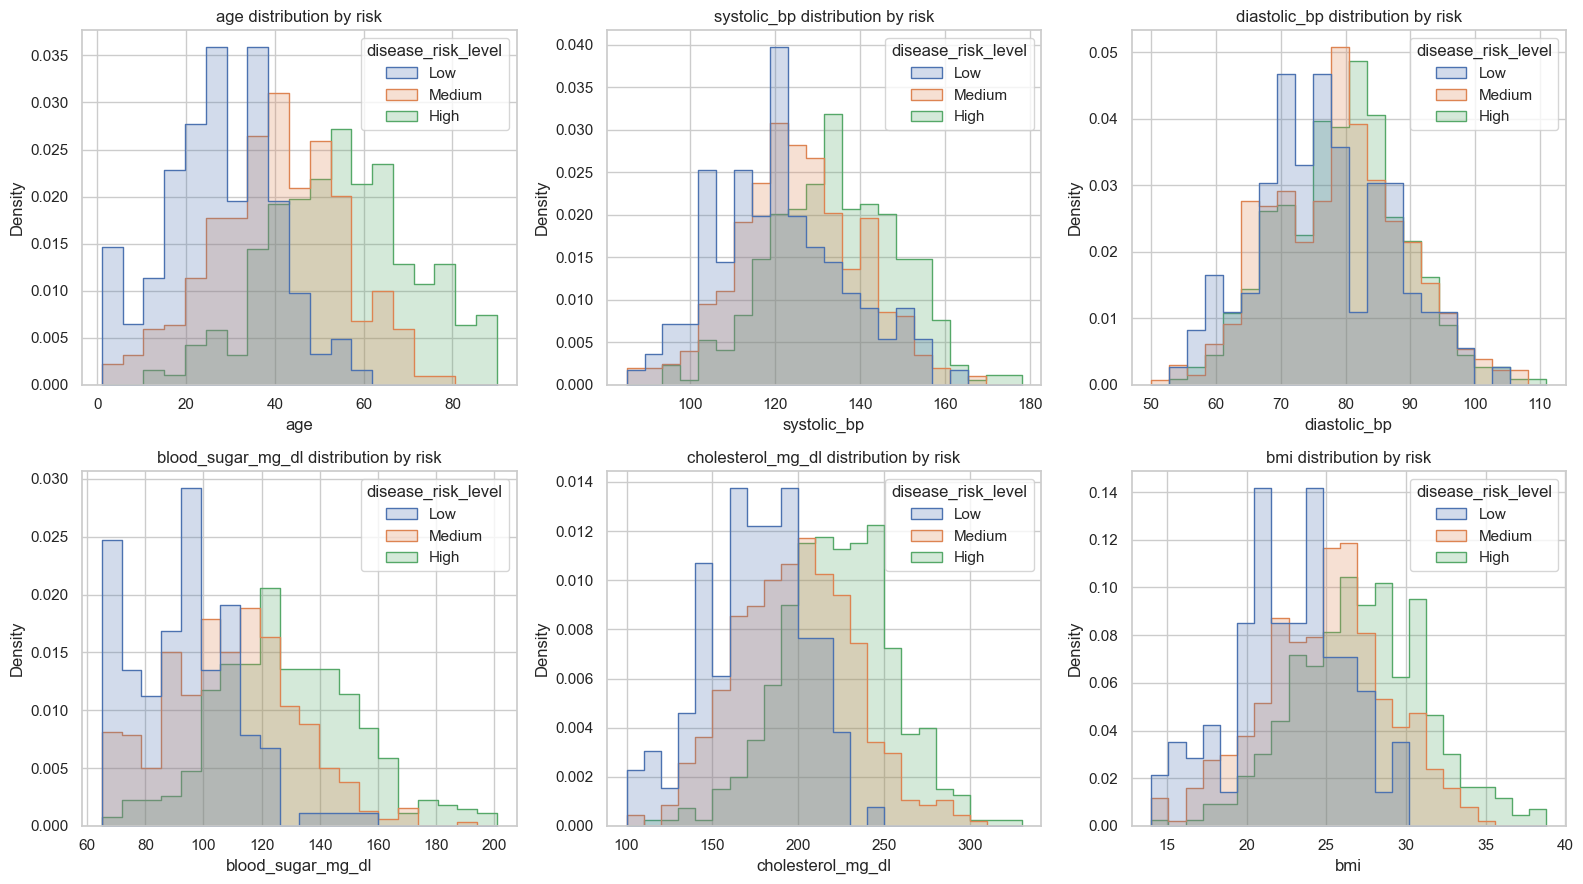

In [11]:
# Histograms of clinical features by risk level
clinical_numeric = [
    "age", "systolic_bp", "diastolic_bp",
    "blood_sugar_mg_dl", "cholesterol_mg_dl", "bmi"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for column, ax in zip(clinical_numeric, axes.flat):
    sns.histplot(data=df, x=column, hue=TARGET, hue_order=RISK_ORDER,
                 element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{column} distribution by risk")
plt.tight_layout()
plt.show()

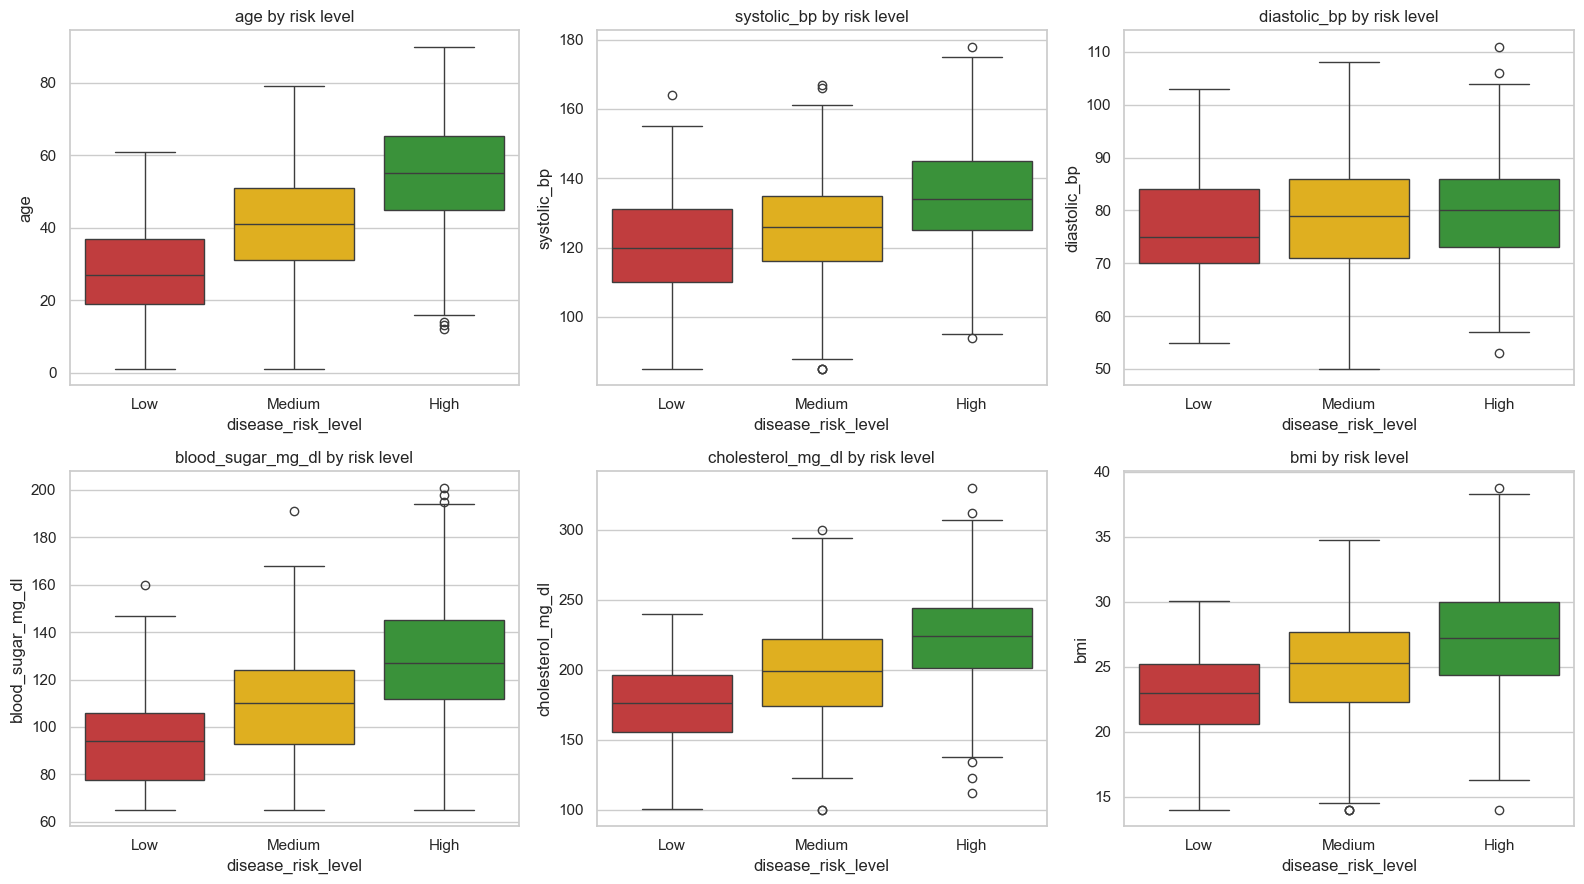

In [12]:
# Boxplots of clinical features by risk level
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for column, ax in zip(clinical_numeric, axes.flat):
    sns.boxplot(data=df, x=TARGET, y=column, order=RISK_ORDER, hue=TARGET,
                palette=["#2ca02c", "#ffbf00", "#d62728"], legend=False, ax=ax)
    ax.set_title(f"{column} by risk level")
plt.tight_layout()
plt.show()

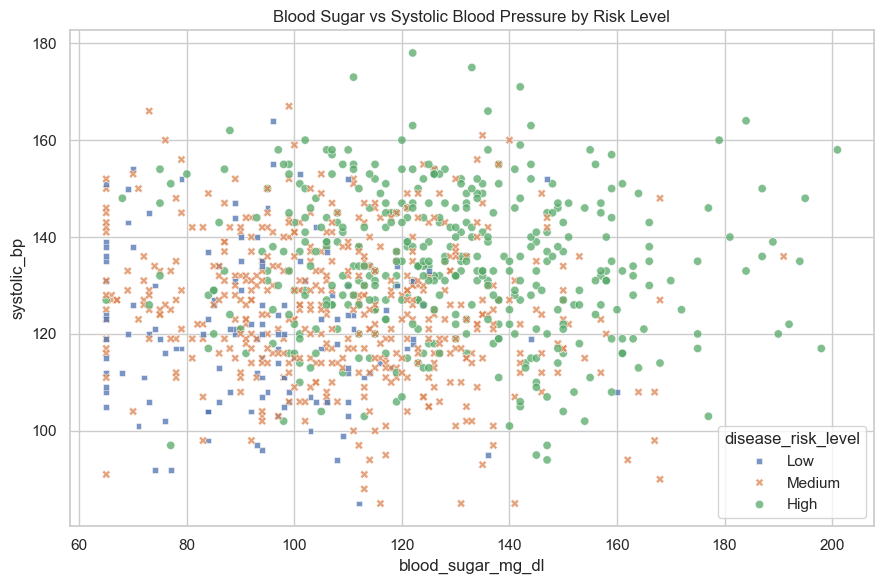

In [13]:
# Scatterplot of blood sugar vs blood pressure by risk level
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="blood_sugar_mg_dl", y="systolic_bp",
                hue=TARGET, hue_order=RISK_ORDER, style=TARGET, alpha=0.75)
plt.title("Blood Sugar vs Systolic Blood Pressure by Risk Level")
plt.tight_layout()
plt.show()

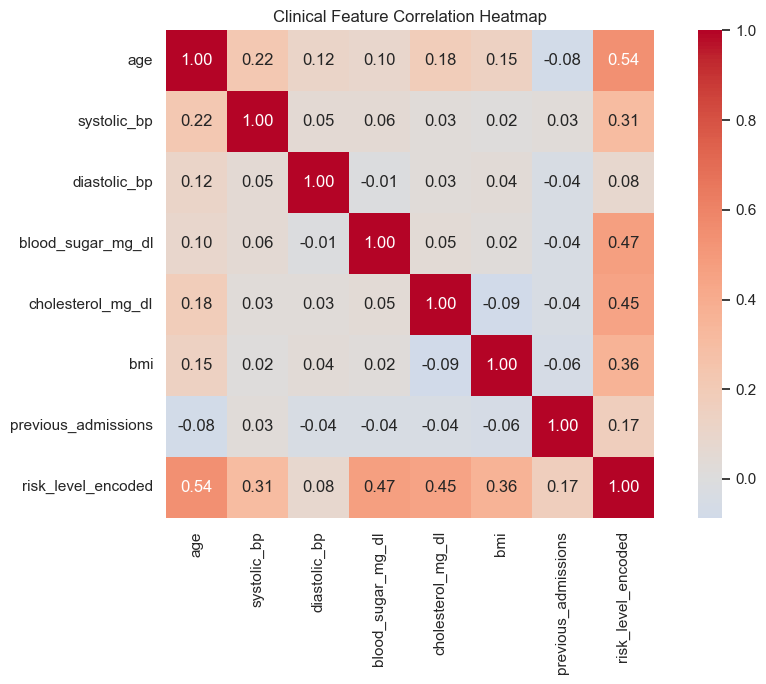

In [14]:
# Correlation heatmap of clinical features and risk level
risk_encoded = df[TARGET].map({"Low": 0, "Medium": 1, "High": 2})
correlation_data = df[clinical_numeric + ["previous_admissions"]].copy()
correlation_data["risk_level_encoded"] = risk_encoded

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_data.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True)
plt.title("Clinical Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [15]:
# Summary statistics of clinical features grouped by risk level
risk_group_summary = (
    df.groupby(TARGET, observed=False)[clinical_numeric + ["previous_admissions"]]
      .agg(["mean", "median", "std"])
      .reindex(RISK_ORDER)
      .round(2)
)
display(risk_group_summary)

age               systolic_bp                \
                     mean median    std        mean median    std   
disease_risk_level                                                  
Low                 27.56   27.0  12.82      121.11  120.0  15.63   
Medium              40.49   41.0  14.69      125.57  126.0  14.41   
High                55.36   55.0  16.13      134.16  134.0  14.74   

                   diastolic_bp               blood_sugar_mg_dl                \
                           mean median    std              mean median    std   
disease_risk_level                                                              
Low                       76.64   75.0  10.17             93.31   94.0  19.15   
Medium                    78.83   79.0  10.32            109.04  110.0  22.67   
High                      79.54   80.0   9.59            128.67  127.0  24.27   

                   cholesterol_mg_dl                  bmi               \
                                mean median    std   mean median   std   
disease_risk_level                                                       
Low                           174.22  176.0  29.21  22.63   23.0  3.62   
Medium                        198.28  199.0  34.02  24.92   25.3  4.00   
High                          222.50  224.0  32.50  27.16   27.2  4.05   

                   previous_admissions               
                                  mean median   std  
disease_risk_level                                   
Low                               0.56    0.0  0.79  
Medium                            0.78    1.0  0.89  
High                              1.03    1.0  1.05

## 8. Findings and Decisions

- The project uses Option C with `disease_risk_level` as the target.
- The prediction point is initial assessment.
- The supplied data contain 1,000 records and 33 attributes.
- The Low class is the minority and requires class-specific evaluation.
- `room_type` missingness is mainly structural, but the feature is excluded because it occurs after the prediction point.
- Identifiers, other targets, operational outcomes, treatment variables, and financial variables are excluded from modelling.
- Two candidate feature sets will be compared clinical only and context-augmented.
- The test set will remain untouched during preprocessing, feature selection, and hyperparameter tuning.
- The project is a methodological educational prototype and not a clinically validated diagnostic system.